In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Data


In [3]:
df = pd.read_csv("../data/final/cleaned_issues.csv")
print(f"Loaded {len(df)} records.")
df[["clean_title", "sentiment_score", "sentiment_label", "frustration_level"]].head()

Loaded 852 records.


,clean_title,sentiment_score,sentiment_label,frustration_level
0,rate limiting,0.7579,positive,0.12105
1,no code change,-0.2960,negative,0.64800
2,rate limitation,0.6715,positive,0.16425
3,rate limitation,0.6715,positive,0.16425
4,rate limitation,0.6715,positive,0.16425


## 2. Feature Distributions


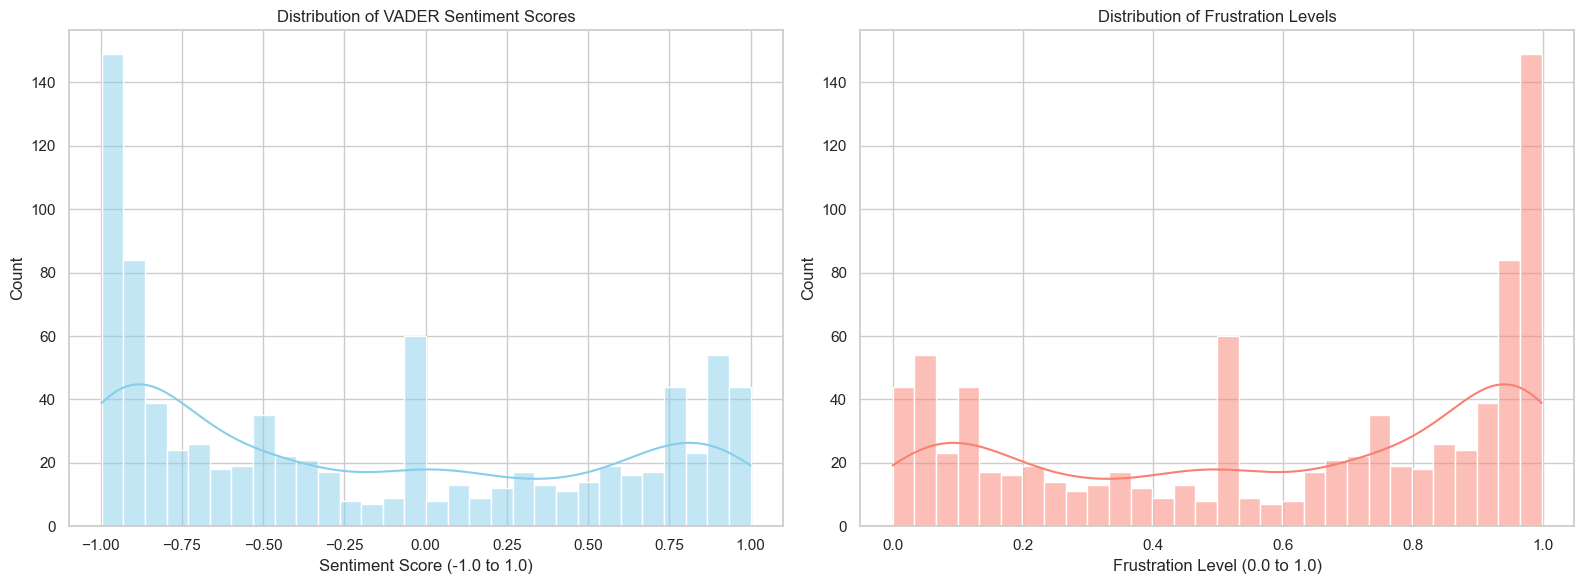

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df["sentiment_score"], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of VADER Sentiment Scores")
axes[0].set_xlabel("Sentiment Score (-1.0 to 1.0)")

sns.histplot(df["frustration_level"], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribution of Frustration Levels")
axes[1].set_xlabel("Frustration Level (0.0 to 1.0)")

plt.tight_layout()
plt.show()

## 3. VADER vs TextBlob Comparison


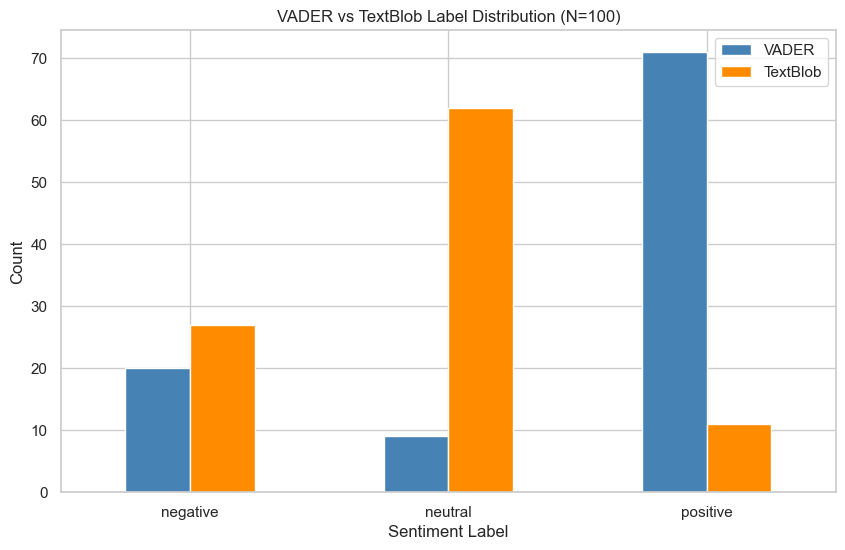

In [5]:
sample_df = df.head(100).copy()

def get_textblob_label(text: str):
    if not isinstance(text, str):
        return "neutral"
    score = TextBlob(text).sentiment.polarity
    if score <= -0.05: return "negative"
    elif score >= 0.05: return "positive"
    return "neutral"

texts = sample_df["clean_title"].fillna("") + " " + sample_df["clean_body"].fillna("")
sample_df["textblob_label"] = texts.apply(get_textblob_label)

vader_counts = sample_df["sentiment_label"].value_counts()
textblob_counts = sample_df["textblob_label"].value_counts()

comparison_df = pd.DataFrame({
    "VADER": vader_counts,
    "TextBlob": textblob_counts
}).fillna(0)

comparison_df.plot(kind="bar", figsize=(10, 6), color=["steelblue", "darkorange"])
plt.title("VADER vs TextBlob Label Distribution (N=100)")
plt.ylabel("Count")
plt.xlabel("Sentiment Label")
plt.xticks(rotation=0)
plt.show()

## 4. Correlation Analysis


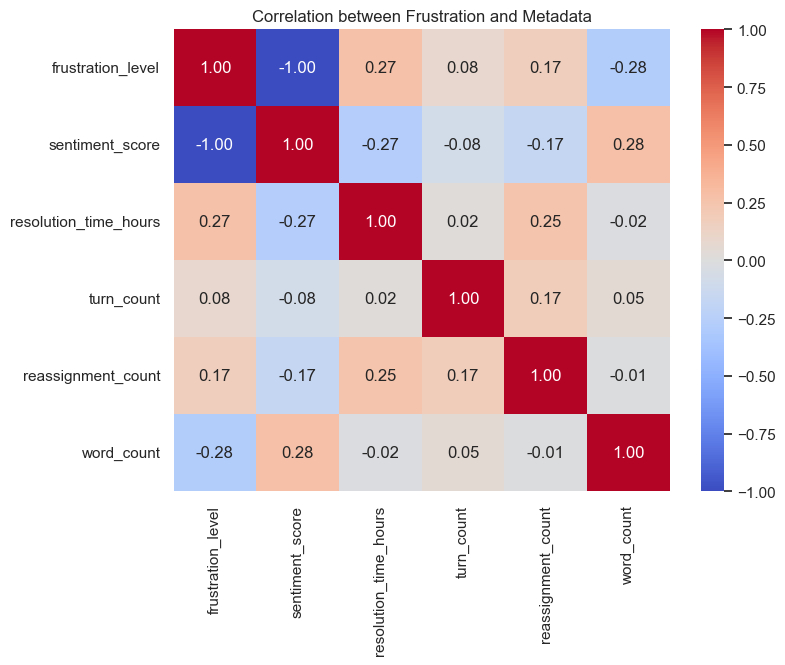

In [6]:
cols_of_interest = ["frustration_level", "sentiment_score", "resolution_time_hours", "turn_count", "reassignment_count", "word_count"]
existing_cols = [c for c in cols_of_interest if c in df.columns]

corr = df[existing_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation between Frustration and Metadata")
plt.show()

# 5.Live Demo  

In [1]:
# --- Fix import path ---
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# --- Import ---
from nlp.sentiment_analyzer import predict

# --- Sample text ---
text = "The system crashed multiple times and I lost all my progress. This is very frustrating."

# --- Run prediction ---
result = predict(
    text=text,
    urgency="high",
    resolution_hours=48
)

# --- Output ---
print("Input Text:")
print(text)

print("\n--- Prediction ---")
print(f"Score        : {result['sentiment_score']}")
print(f"Label        : {result['sentiment_label']}")
print(f"Frustration  : {result['frustration_level']}")

Input Text:
The system crashed multiple times and I lost all my progress. This is very frustrating.

--- Prediction ---
Score        : -0.4005
Label        : negative
Frustration  : 0.9002


## Model Selection Decision:

- VADER is selected as the primary model because:
  - deterministic outputs (important for RL)
  - better handling of short technical text
  - stable sentiment distribution
- TextBlob is used only for comparison